# Latent-space discovery of metastable dynamical regimes

Here we are interested in decomposing the static ponderomotive instability of superconducting radio frequency cavities.

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = f'{root_dir}/data/regimes/cavity_fold'

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import util_data
import util_nn

### Read windows data

In [2]:
# --! set seed to get reproducible behavior
util_nn.set_seed(2026)

In [3]:
class regime_dataset(torch.utils.data.Dataset):

    def __init__(self, data, back_nsample, fore_nsample):

        self.data = torch.as_tensor(data)

        self.back_nsample = back_nsample
        self.fore_nsample = fore_nsample

        self.index = []

        ntraj = self.data.shape[0]
        nsample = self.data.shape[1]

        for traj_id in range(ntraj):

            for center in range(back_nsample,
                                nsample - fore_nsample):

                self.index.append(
                    (traj_id, center)
                )

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):

        traj_id, center = self.index[idx]

        x = self.data[traj_id]

        back = x[
            center-self.back_nsample:center
        ]

        fore = x[
            center:center+self.fore_nsample
        ]

        return (
            back,
            fore,
            traj_id,
            center
        )

In [4]:
def normalize_standard(timeseries, mean, std):
    return (timeseries - mean) / std

def denormalize_standard(timeseries, mean, std):
    return timeseries * std + mean

class dataset(torch.utils.data.Dataset):
    def __init__(self, back, fore):
        self.back = back
        self.fore = fore

    def __len__(self):
        return len(self.back)

    def __getitem__(self, idx):
        return self.back[idx], self.fore[idx]

# --! read windows data from a file
traj_nsample = 2000
window_nsample = 72
data = util_data.read_datafile(f'{data_dir}/trajectories', traj_nsample)
print(f'inf > read data shape: {data.shape}')

# --! get normalization constants per channel
std_min = torch.tensor(1e-3, dtype=torch.float32)
data_mean = [d.mean() for d in torch.split(data, 1, dim=-1)]
data_std = [torch.maximum(d.std(), std_min) for d in torch.split(data, 1, dim=-1)]

# --! normalize data
data = torch.cat([
    normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), data_mean, data_std)], dim=-1)

# --! split windows into lookback and forecast parts
fore_nsample = 24
back_nsample = 2 * fore_nsample

dataset = regime_dataset(data, back_nsample, fore_nsample)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=False)

inf > read data shape: torch.Size([8, 2000, 2])


### Instantiate past and future regime encoders

The idea is to train a latent space that is future-aware. When our trained encoder looks at past data (from a lookback window) it is expected to produce a coordinate $c_t$ which represents the evolution of dynamics. A threshold can later be derived to separate various dynamical regimes.

In [5]:
# --! instantiate encoders
window_ndim = data.shape[-1]
latent_ndim = 3
back_enc = kind.regime_encoder(back_nsample, window_ndim, latent_ndim)
fore_enc = kind.regime_encoder(fore_nsample, window_ndim, latent_ndim)

In [6]:
def slow_feature_loss(z, traj_id, center, lag=1):
    loss = 0.0
    count = 0

    for traj in torch.unique(traj_id):

        idx = (traj_id == traj)

        z_traj = z[idx]
        c_traj = center[idx]

        order = torch.argsort(c_traj)

        z_traj = z_traj[order]

        dz = z_traj[lag:] - z_traj[:-lag]

        loss += (dz**2).mean()

        count += 1

    return loss / max(count,1)

def variance_loss(z):

    std = torch.sqrt(z.var(dim=0) + 1e-4)
    return torch.mean(torch.relu(1.0 - std))

def train_enc(back_enc, fore_enc, dataloader, nepoch=100, lag=1):
    optimizer = torch.optim.Adam(list(back_enc.parameters()) + list(fore_enc.parameters()), lr=1e-3)

    for epoch in range(nepoch):
        total_loss = 0.0

        for back, fore, traj_id, center in dataloader:
            z = back_enc(torch.flatten(back, start_dim=1))
            h = fore_enc(torch.flatten(fore, start_dim=1))

            loss_future = F.mse_loss(z, h)
            loss_var_z = variance_loss(z)
            loss_var_h = variance_loss(h)

            loss_slow = slow_feature_loss(z[:, 2], traj_id, center, lag=lag)

            loss = (
                loss_future
                + 0.01 * loss_var_z + 0.01 * loss_var_h
                + 0.1 * loss_slow
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")


In [7]:
train_enc(back_enc, fore_enc, dataloader, nepoch=200, lag=10)

epoch 0, loss: 0.045447
epoch 20, loss: 0.019660
epoch 40, loss: 0.019257
epoch 60, loss: 0.019176
epoch 80, loss: 0.019111
epoch 100, loss: 0.019445
epoch 120, loss: 0.018159
epoch 140, loss: 0.017440
epoch 160, loss: 0.019986
epoch 180, loss: 0.021629


In [8]:

# --! once more, prepare lookback and forecast windows
data = util_data.read_datafile(f'{data_dir}/windows', window_nsample)

# --! normalize data
data = torch.cat([
    normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), data_mean, data_std)], dim=-1)

back, fore = torch.split(data, [back_nsample, fore_nsample], dim=-2)

# --! encode lookback windows
z = back_enc(torch.flatten(back, start_dim=1))
z_np = z.detach().cpu().numpy()


A metastable region is some neighborhood of an attracting invariant set. Learn a latent coordinate $c_t$. The coordinate evolves slowly inside regimes. The coordinate changes rapidly when the dynamics reorganize. That suggests defining risk through latent motion, not through a specific geometric interpretation.

We define metastable sets through persistence:

$$
\mathcal{N} = \{ z_t \; \colon \rho_t < \rho^{\star} \},
$$

and

$$
\mathcal{E} = \{ z_t \; \colon \rho_t \ge \rho^{\star} \},
$$

where $\rho_t = \lvert \frac{dc}{dt} \rvert$.

So a metastable set is a region where trajectories remain for long periods. Long residence time implies small latent velocity.

So conceptually the logic becomes

$$
z \rightarrow \rho \rightarrow \text{metastable regions}
$$

Advantage over immediate KMeans clustering:

* No need to choose the number of clusters
* No need to determine what cluster represents what

torch.Size([15432, 72, 2])
13503
15424


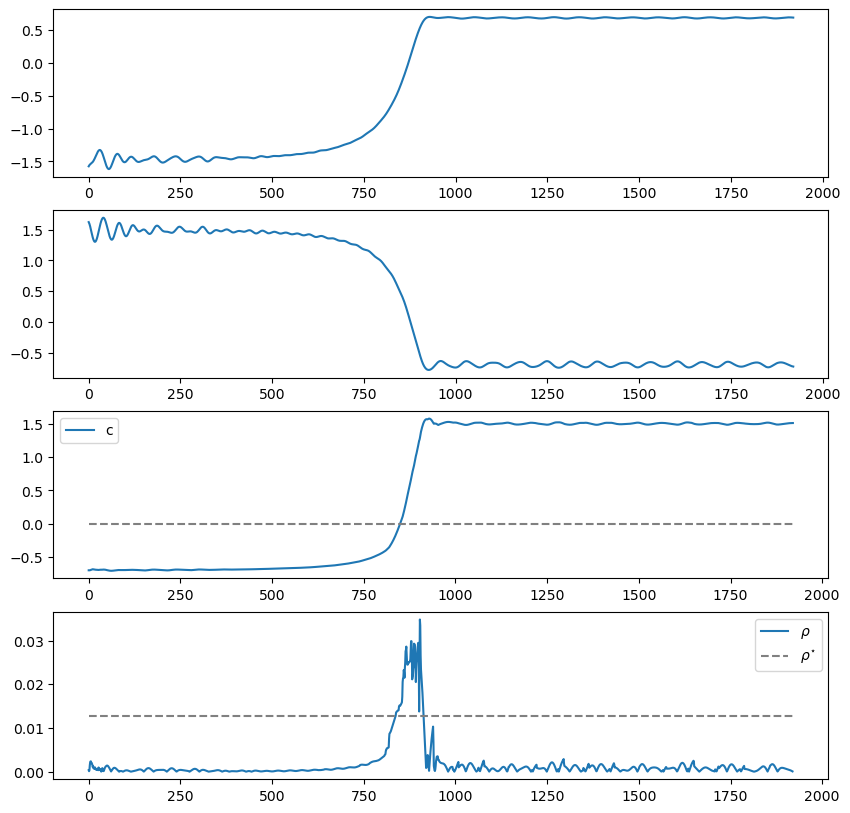

In [9]:
data_nsample = traj_nsample - window_nsample
jdata = 7
data_start = jdata * (data_nsample + 1)
data_end = (jdata + 1) * data_nsample

print(data.shape)
print(data_start)
print(data_end)

plt.figure(figsize=(10,10))

plt.subplot(4,1,1)
plt.plot(data[data_start:data_end, 48, 0])

plt.subplot(4,1,2)
plt.plot(data[data_start:data_end, 48, 1])

c = z_np[data_start:data_end, 2]

plt.subplot(4,1,3)
plt.plot(c, label='c')
plt.plot([0, len(c)], [0, 0], color='gray', linestyle='dashed')
plt.legend()

dc = np.abs(np.diff(c))
dc_star = np.percentile(dc, 96)

plt.subplot(4,1,4)
plt.plot(dc, label='$\\rho$')
plt.plot([0, len(c)], [dc_star, dc_star], color='gray', linestyle='dashed', label='$\\rho^{\\star}$')
plt.legend()

plt.show()

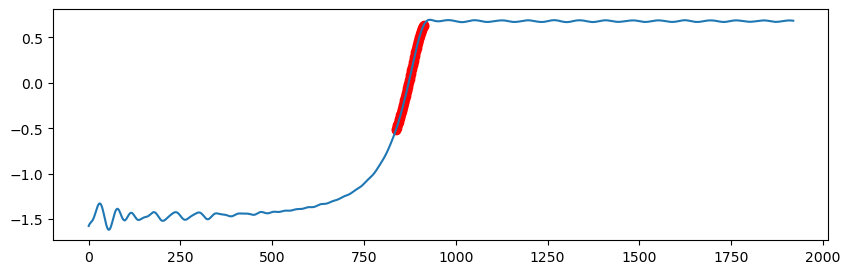

In [10]:
test_data = data[data_start:(data_end - 1), 48, 0]
test_time = np.arange(len(test_data))

idx_nom = dc < dc_star
idx_exc = dc >= dc_star

plt.figure(figsize=(10,3))
plt.plot(test_time, test_data)
plt.scatter(test_time[idx_exc], test_data[test_time[idx_exc]], color='red')
plt.show()